# Notebook 2: Exploratory Data Analysis and Feature Engineering

**Notebook Purpose**
This notebook explores the training data and prepares features for modeling:
1. Exploratory data analysis on training data only (distributions, correlations, patterns)
2. Create derived features (ocean color indices, seasonal features)
3. Feature selection based on correlation analysis and domain knowledge
4. Save preprocessed features for model training

**Key Outputs**
- `Training Set.csv`: Training set without outliers and with engineered features
- `Validation Set.csv`: Validation set with same transformations applied
- `Testing Set.csv`: Test set with same transformations applied

**Data Leakage Prevention**
All EDA, feature selection, and feature engineering performed on training data only. Same transformations (with training-derived parameters) applied to validation and test sets. Test and validation sets are not examined during exploration.

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import skew

## Data Ingestion

In [2]:
training_set_file_path = '../Data/Data Splits/Unprocessed/Training Set.csv'
validation_set_file_path = '../Data/Data Splits/Unprocessed/Validation Set.csv'
testing_set_file_path = '../Data/Data Splits/Unprocessed/Testing Set.csv'

training_df = pd.read_csv(training_set_file_path)
validation_df = pd.read_csv(validation_set_file_path)
testing_df = pd.read_csv(testing_set_file_path)

training_df.head()
# validation_df.head()
# testing_df.head

,Cast_id,Latitude,Longitude,Year,Month,Day,Oxygen,Date,chlor_a,poc,...,Rrs_412,Rrs_443,Rrs_469,Rrs_488,Rrs_531,Rrs_547,Rrs_555,Rrs_645,Rrs_667,Rrs_678
0,13547689,54.4027,18.9570,2002,7,4,302.0,2002-07-04,8.417533,328.200012,...,0.002044,0.001598,0.001790,0.001616,0.002596,0.002656,0.002612,0.000610,0.000410,0.000472
1,13547708,60.3885,27.6550,2002,7,4,314.0,2002-07-04,18.162699,581.000000,...,0.000892,0.001096,0.001390,0.001538,0.002776,0.003146,0.003194,0.001868,0.001632,0.001528
2,13547707,60.2530,27.2468,2002,7,4,311.0,2002-07-04,12.316717,564.599976,...,0.001150,0.000894,0.001390,0.001374,0.002294,0.002532,0.002534,0.001382,0.001196,0.001146
3,13547706,54.5772,18.8613,2002,7,4,343.0,2002-07-04,2.442546,220.199997,...,0.003256,0.002724,0.002788,0.002608,0.003222,0.003062,0.002840,0.000760,0.000564,0.000568
4,13547705,54.5720,18.8230,2002,7,4,336.0,2002-07-04,3.658302,250.399994,...,0.003024,0.002490,0.002606,0.002408,0.003170,0.003150,0.002944,0.000736,0.000494,0.000486


## Exploratory Data Analysis

In [3]:
# Define columns to exclude from analysis
exclude_cols = ['Cast_id', 'Year', 'Month', 'Day', 'Date']

# Separate into numeric and categorical (excluding unwanted columns)
numeric_cols = [col for col in training_df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]
categorical_cols = [col for col in training_df.select_dtypes(exclude=[np.number]).columns if col not in exclude_cols]

# Display the lists of numeric and categorical variables for reference
print("Numeric Variables: "+str(numeric_cols))
print("Categorical Variables: "+str(categorical_cols))

# Generate descriptive statistics for numeric variables
training_df[numeric_cols].describe().T

Numeric Variables: ['Latitude', 'Longitude', 'Oxygen', 'chlor_a', 'poc', 'sst', 'Rrs_412', 'Rrs_443', 'Rrs_469', 'Rrs_488', 'Rrs_531', 'Rrs_547', 'Rrs_555', 'Rrs_645', 'Rrs_667', 'Rrs_678']
Categorical Variables: []


,count,mean,std,min,25%,50%,75%,max
Latitude,35229.0,35.272087,30.572316,-78.571600,29.028000,48.681900,56.315000,82.125700
Longitude,35229.0,10.993683,82.869357,-179.988000,-53.733300,13.905000,25.123000,179.922700
Oxygen,35229.0,282.936852,91.567542,-0.392000,229.000000,272.000000,325.773000,9261.200000
chlor_a,35229.0,5.296494,10.562114,0.009997,0.327609,1.523265,4.950909,99.608688
poc,35229.0,504.576829,1106.058538,13.200000,86.599998,212.800003,426.500000,12953.400391
sst,35229.0,15.510802,7.570622,-1.770000,9.932500,16.350000,20.664999,33.239998
Rrs_412,35229.0,0.003871,0.004175,-0.002932,0.001022,0.002416,0.005258,0.032276
Rrs_443,35229.0,0.003497,0.003191,-0.000864,0.001162,0.002413,0.004904,0.031364
Rrs_469,35229.0,0.003637,0.002770,-0.000228,0.001547,0.002768,0.005042,0.031466
Rrs_488,35229.0,0.003412,0.002404,0.000286,0.001632,0.002764,0.004674,0.030229


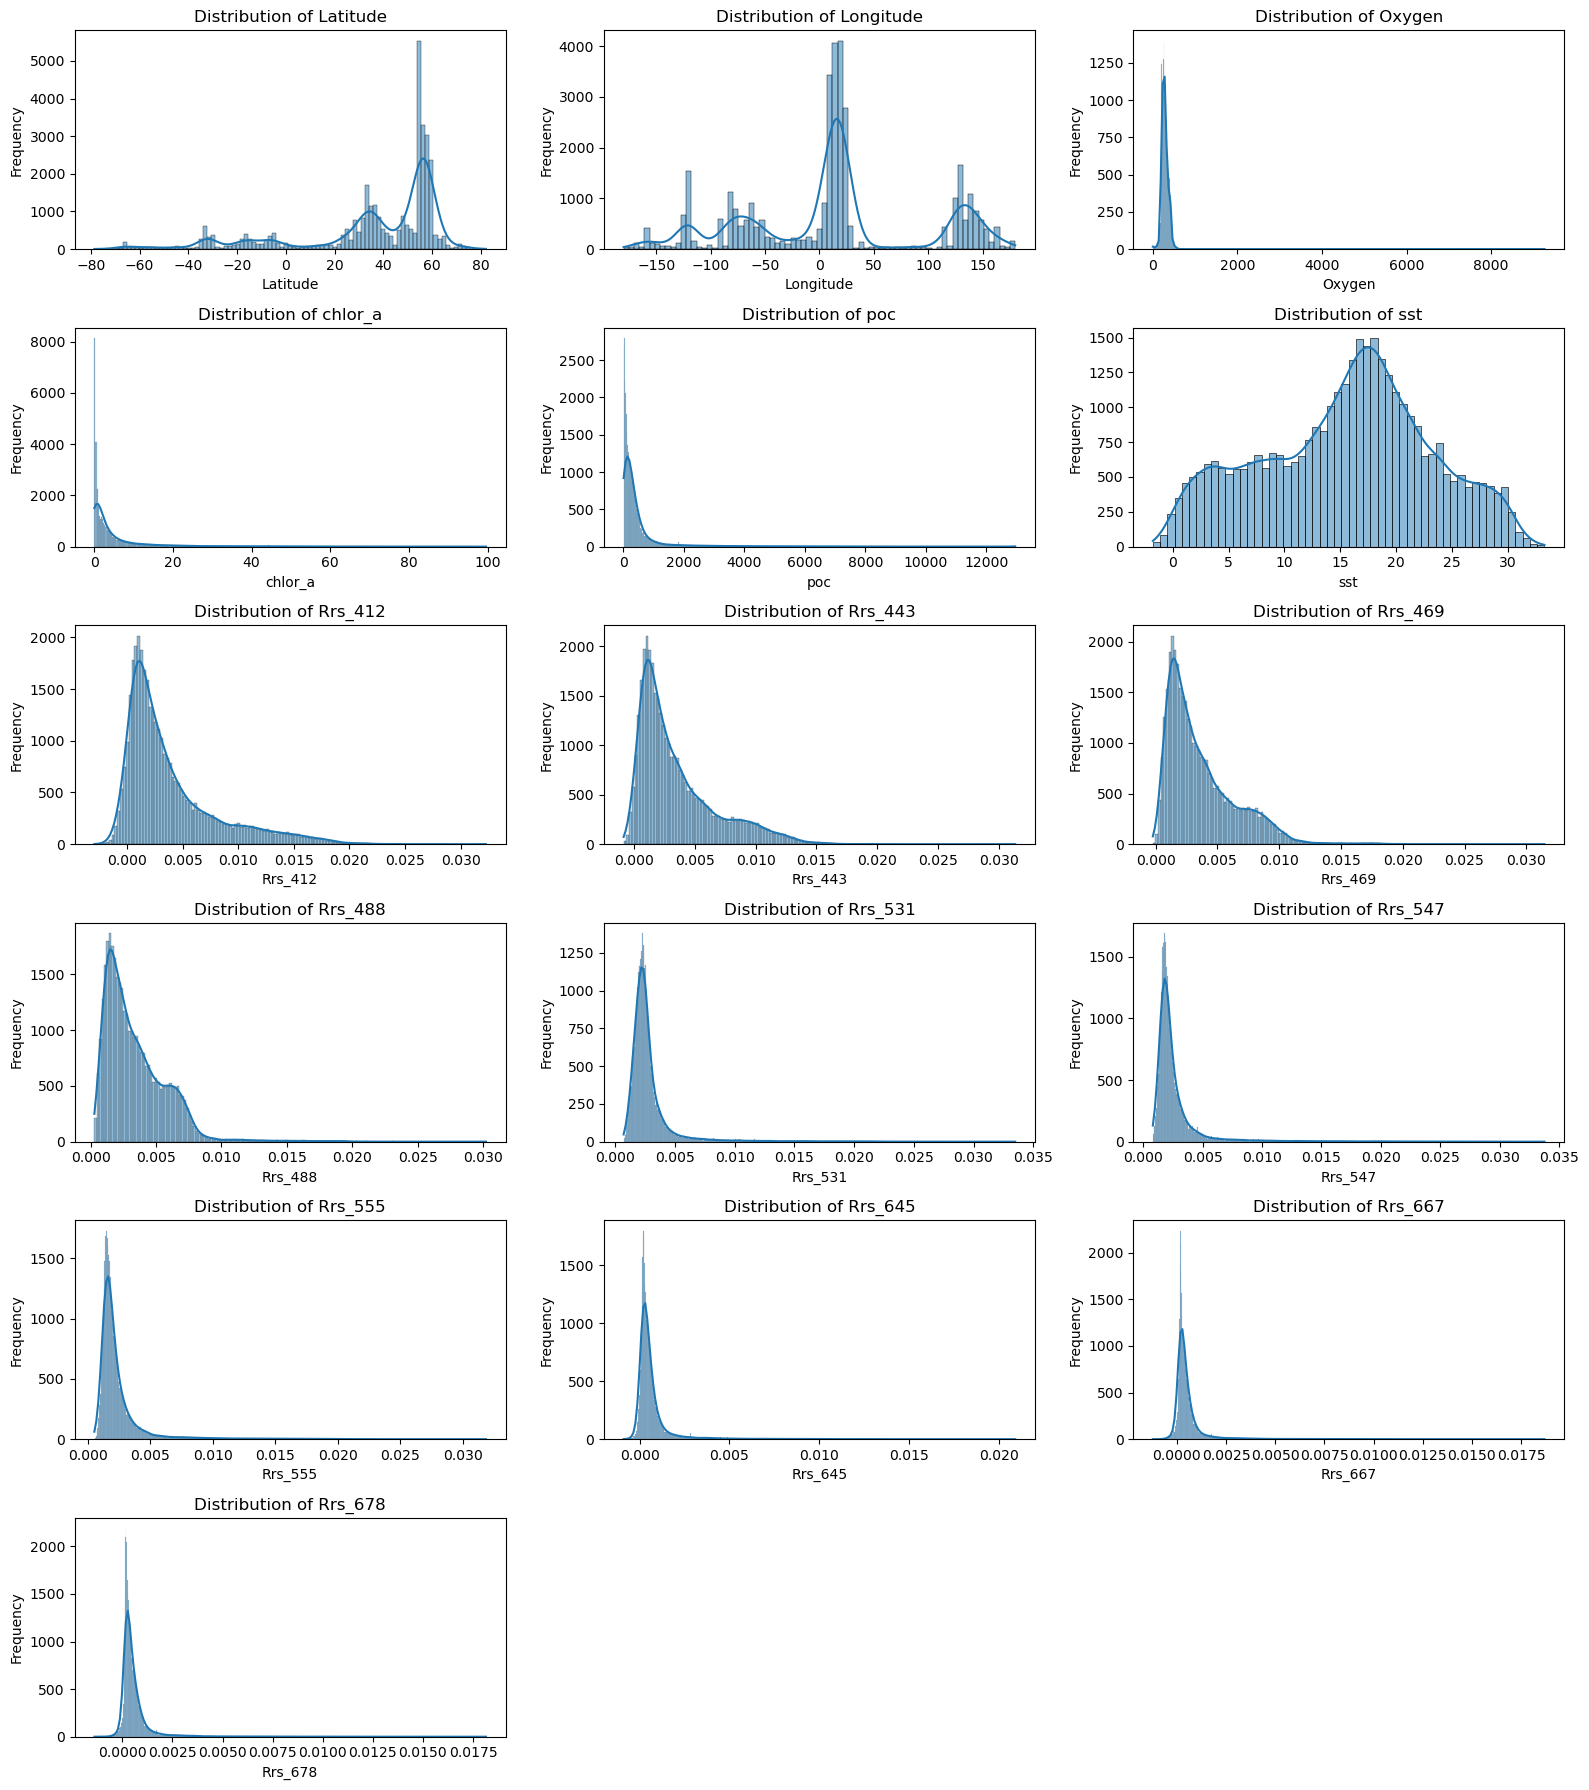

In [5]:
def plot_numeric_histograms(df, numeric_cols, figsize=(16, 3*math.ceil(len(numeric_cols)/3))):
   """
   Create histograms for numeric columns arranged in subplots.
   Uses clean display names for titles and labels.

   Parameters:
   -----------
   df : pandas.DataFrame
       The dataframe containing the numeric columns to plot
   numeric_cols : list
       List of numeric column names to create histograms for
   figsize : tuple, optional
       Figure size as (width, height) in inches, default dynamically calculated based on column count
   """
   # Calculate layout dimensions
   n_plots = len(numeric_cols)
   n_cols = 3
   n_rows = math.ceil(n_plots / n_cols)

   # Create the figure and subplots
   fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
   axes = axes.flatten() if n_rows * n_cols > 1 else [axes]  # Flatten if multiple plots

   # Create a histogram for each numeric column
   for i, col in enumerate(numeric_cols):
       if i < len(axes):
           # Plot histogram with KDE (Kernel Density Estimation) curve
           sns.histplot(df[col], kde=True, ax=axes[i])
           axes[i].set_title(f'Distribution of {col}')
           axes[i].set_xlabel(col)
           axes[i].set_ylabel('Frequency')

   # Hide any unused subplots if odd number of columns
   for j in range(i+1, len(axes)):
       axes[j].set_visible(False)

   # Adjust spacing between subplots for better readability
   plt.subplots_adjust(wspace=0.3, hspace=0.4)
   plt.tight_layout()
   plt.savefig('../Results/Figures/numeric_histograms_plot.png', dpi=300, bbox_inches='tight')
   plt.show()

# Generate histograms for all numeric variables to visualize their distributions
plot_numeric_histograms(training_df, numeric_cols)


Feature Skewness (sorted by absolute value):

Oxygen       29.312821
Rrs_667       6.644455
Rrs_678       6.558587
Rrs_645       6.223321
poc           5.831294
Rrs_531       4.928104
Rrs_547       4.864723
Rrs_555       4.773310
chlor_a       3.998798
Rrs_488       1.952030
Rrs_412       1.589936
Latitude      1.477278
Rrs_469       1.390660
Rrs_443       1.344458
sst           0.164773
Longitude     0.067916
dtype: float64

Highly Skewed Features (|skewness| > 3.5):

Oxygen     29.312821
Rrs_667     6.644455
Rrs_678     6.558587
Rrs_645     6.223321
poc         5.831294
Rrs_531     4.928104
Rrs_547     4.864723
Rrs_555     4.773310
chlor_a     3.998798
dtype: float64


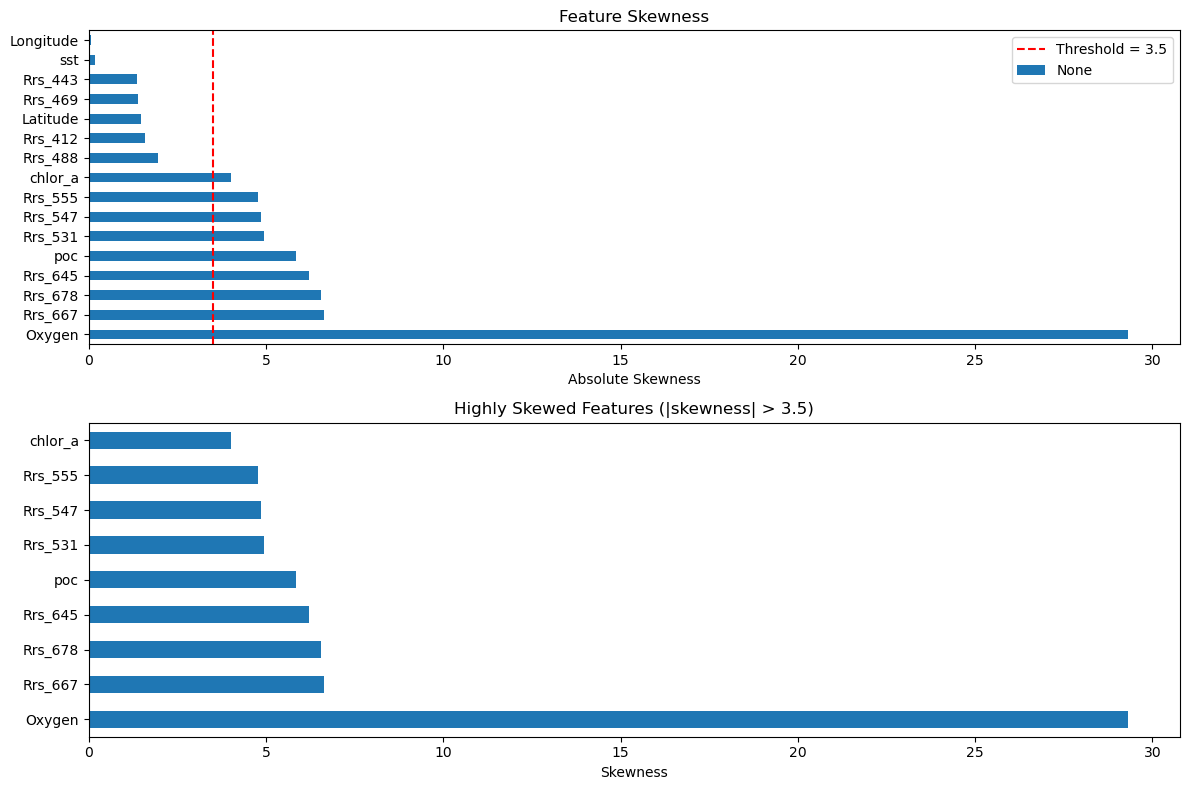

In [6]:
# Check skewness of all numeric features in training data
skewness = training_df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Sort by absolute skewness
skewness_sorted = skewness.abs().sort_values(ascending=False)

print("Feature Skewness (sorted by absolute value):\n")
print(skewness_sorted)

# Identify highly skewed features (common threshold: |skewness| > 3.5)
highly_skewed = skewness[skewness.abs() > 3.5].sort_values(ascending=False)

print("\n" + "="*50)
print("Highly Skewed Features (|skewness| > 3.5):\n")
print(highly_skewed)

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot all skewness
skewness_sorted.plot(kind='barh', ax=axes[0])
axes[0].set_xlabel('Absolute Skewness')
axes[0].set_title('Feature Skewness')
axes[0].axvline(x=3.5, color='red', linestyle='--', label='Threshold = 3.5')
axes[0].legend()

# Plot only highly skewed
if len(highly_skewed) > 0:
    highly_skewed.plot(kind='barh', ax=axes[1])
    axes[1].set_xlabel('Skewness')
    axes[1].set_title('Highly Skewed Features (|skewness| > 3.5)')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('../Results/Figures/feature_skewness_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Outlier Handling

# Check Oxygen outliers
print("\nOxygen quality check:")
print(f"  Min: {training_df['Oxygen'].min():.2f} μmol/kg")
print(f"  Max: {training_df['Oxygen'].max():.2f} μmol/kg")
print(f"  Values > 400: {(training_df['Oxygen'] > 400).sum()}")
print(f"  Values < 0: {(training_df['Oxygen'] < 0).sum()}")

# Define valid range (based on oceanographic knowledge)
valid_oxygen_range = (0, 400)  # μmol/kg
outlier_mask = (training_df['Oxygen'] >= valid_oxygen_range[0]) & \
               (training_df['Oxygen'] <= valid_oxygen_range[1])

n_outliers = (~outlier_mask).sum()
print(f"\nRemoving {n_outliers} outliers ({n_outliers/len(training_df)*100:.2f}%)")

# Apply to all splits
training_df = training_df[outlier_mask].copy()

# Apply same filter to validation and test
validation_df = validation_df[
    (validation_df['Oxygen'] >= valid_oxygen_range[0]) &
    (validation_df['Oxygen'] <= valid_oxygen_range[1])
].copy()

testing_df = testing_df[
    (testing_df['Oxygen'] >= valid_oxygen_range[0]) &
    (testing_df['Oxygen'] <= valid_oxygen_range[1])
].copy()

print(f"\nTraining: {len(training_df):,} samples")
print(f"Validation: {len(validation_df):,} samples")
print(f"Testing: {len(testing_df):,} samples")



Oxygen quality check:
  Min: -0.39 μmol/kg
  Max: 9261.20 μmol/kg
  Values > 400: 2805
  Values < 0: 1

Removing 2806 outliers (7.97%)

Training: 32,423 samples
Validation: 6,922 samples
Testing: 7,103 samples


In [8]:
# Oxygen value analysis

thresholds = {
    'Severe Hypoxia (<22)': (training_df['Oxygen'] < 22).sum(),
    'Hypoxic (22-60)': ((training_df['Oxygen'] >= 22) & (training_df['Oxygen'] < 60)).sum(),
    'Low Oxygen (60-192)': ((training_df['Oxygen'] >= 60) & (training_df['Oxygen'] < 192)).sum(),
    'Normal (192-320)': ((training_df['Oxygen'] >= 192) & (training_df['Oxygen'] < 320)).sum(),
    'High Oxygen (>320)': (training_df['Oxygen'] >= 320).sum()
}

for category, count in thresholds.items():
    pct = count / len(training_df) * 100
    print(f"  {category}: {count:,} ({pct:.1f}%)")

  Severe Hypoxia (<22): 88 (0.3%)
  Hypoxic (22-60): 72 (0.2%)
  Low Oxygen (60-192): 1,444 (4.5%)
  Normal (192-320): 24,123 (74.4%)
  High Oxygen (>320): 6,696 (20.7%)


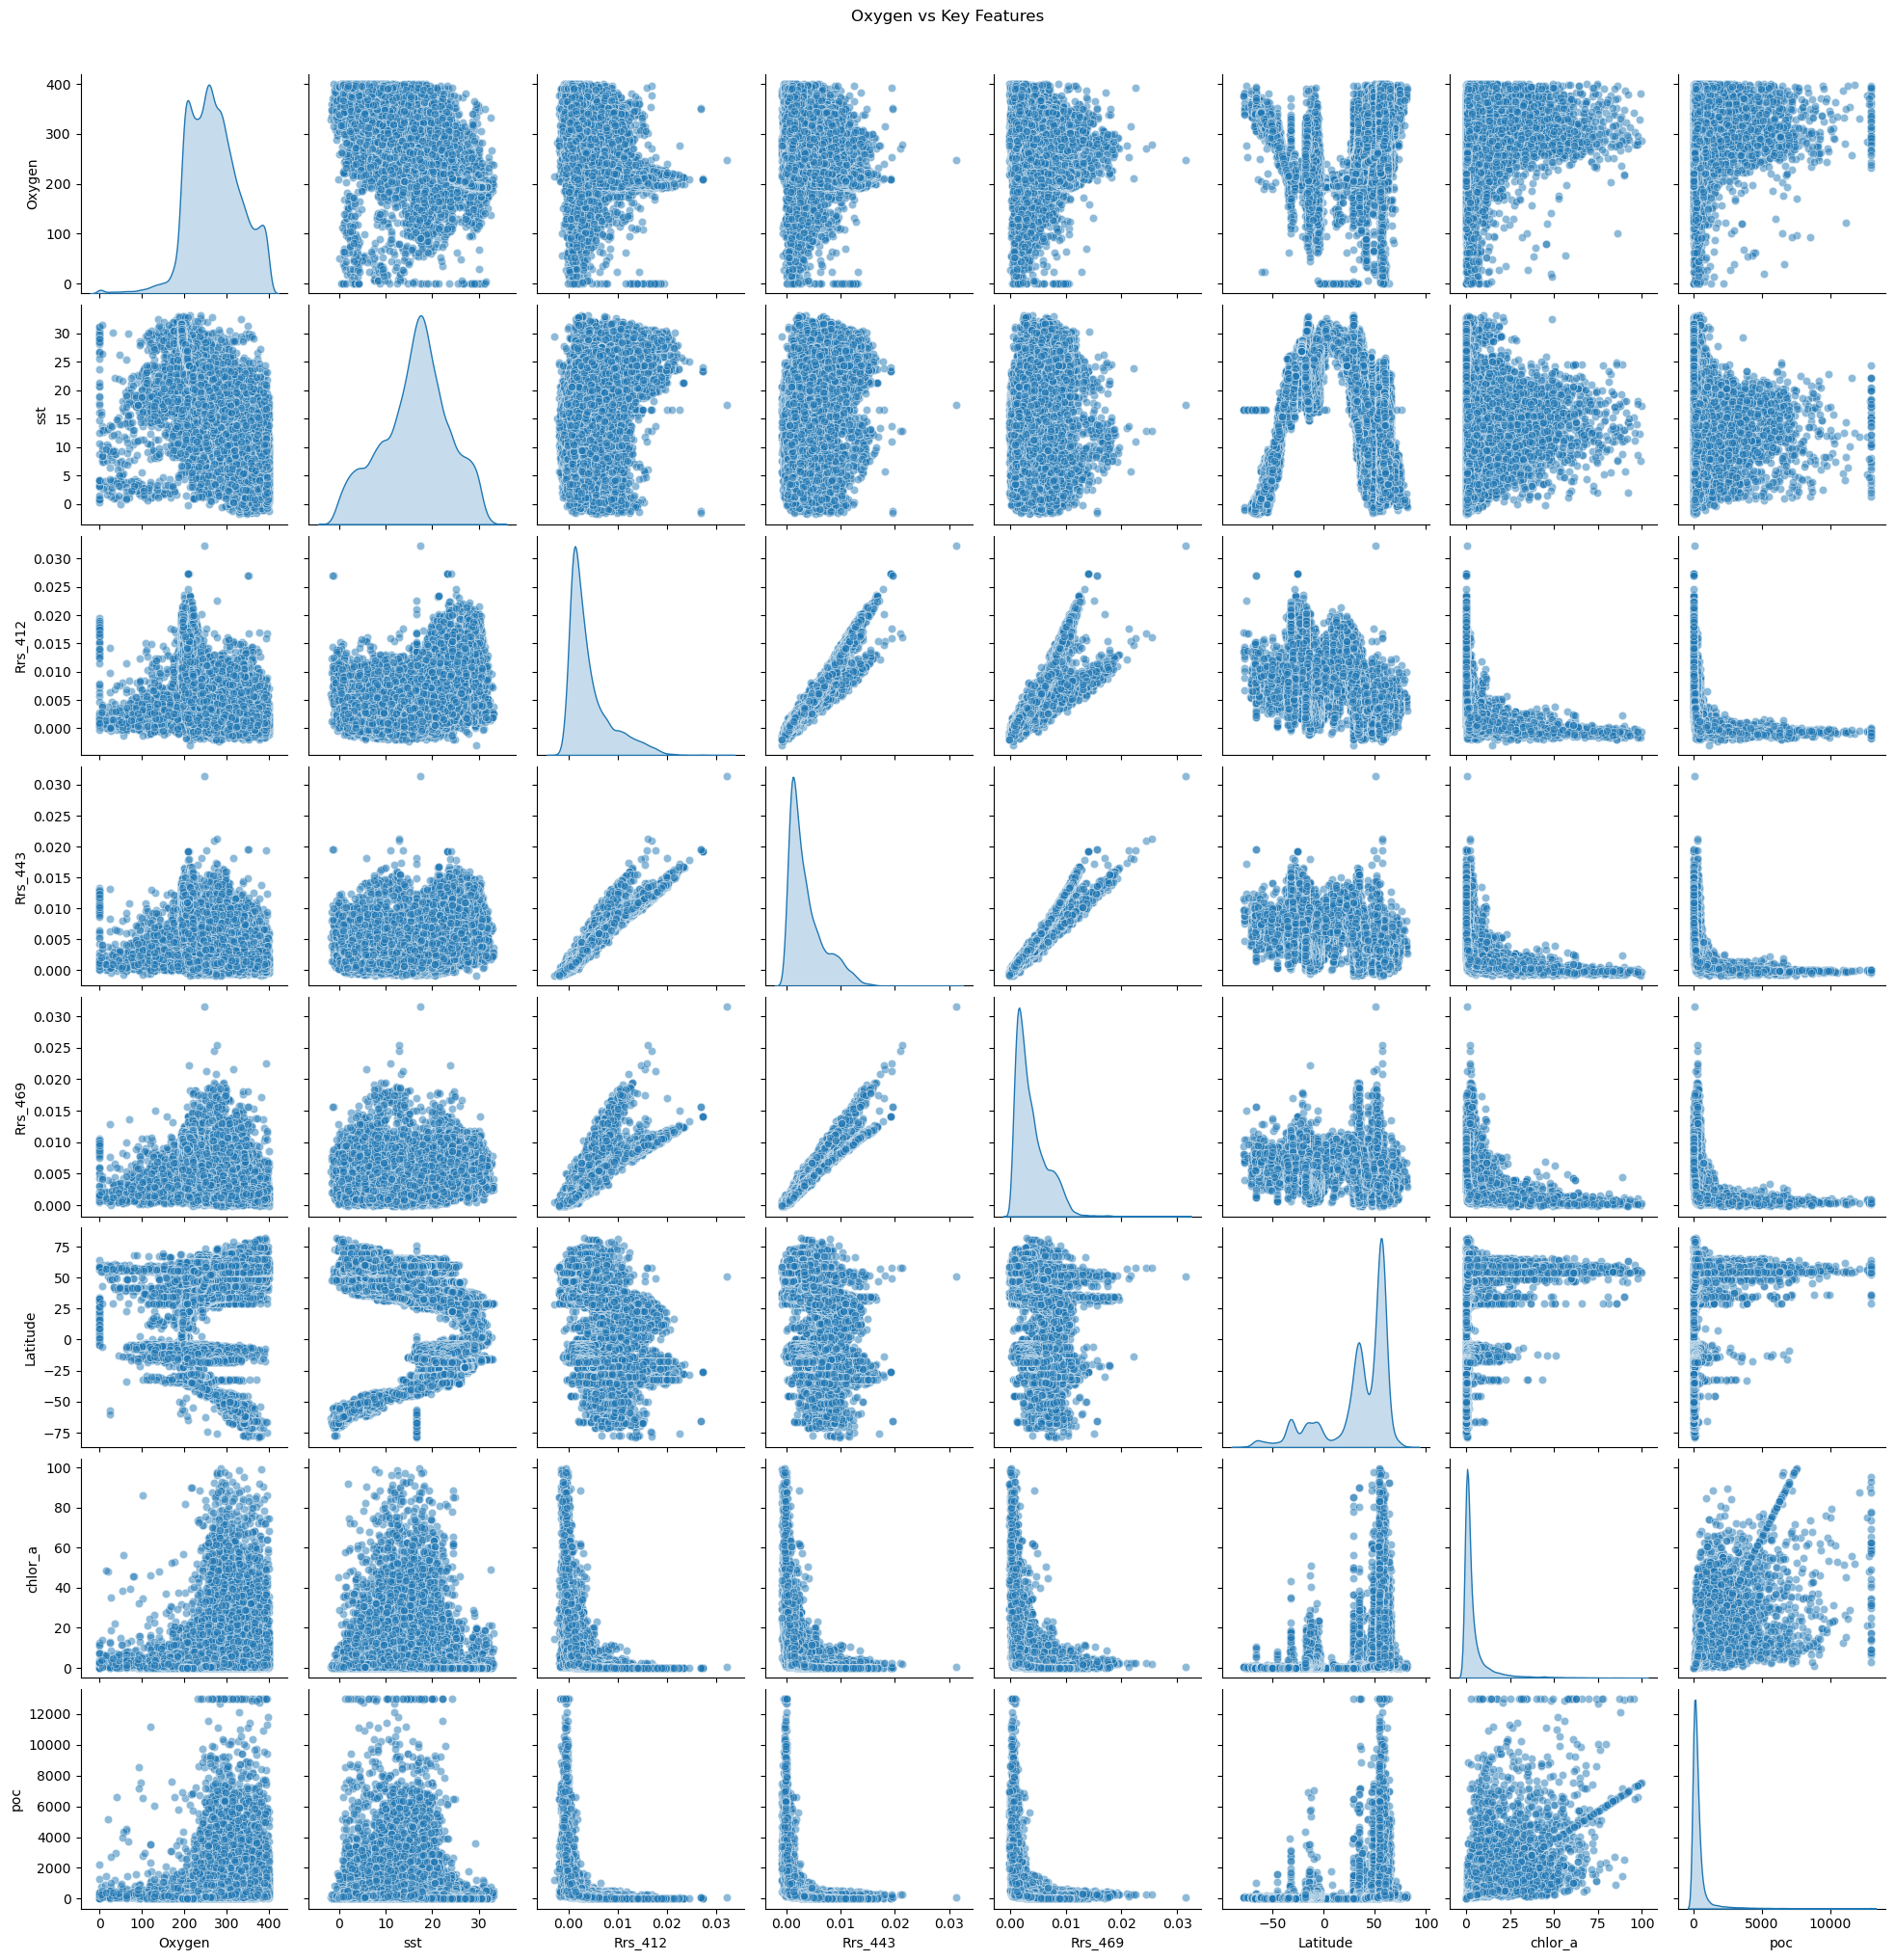

In [9]:
# Select most important features based on correlation (below)
key_features = ['Oxygen', 'sst', 'Rrs_412', 'Rrs_443', 'Rrs_469', 'Latitude', 'chlor_a', 'poc']

# Create scatter plot matrix
sns.pairplot(training_df[key_features], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Oxygen vs Key Features', y=1.02)
plt.savefig('../Results/Figures/oxygen_v_key_features_splom.png', dpi=300, bbox_inches='tight')
plt.show()

### Geographic Coverage Analysis

In [10]:
# Scatter plot unique coordinates
fig = px.scatter_geo(training_df,
                     lat='Latitude',
                     lon='Longitude',
                     title='Data Coverage Map',
                     projection='natural earth',
                     opacity=0.5)

fig.update_traces(marker=dict(size=3, color='blue'))

fig.update_geos(
    showland=True,
    landcolor='lightgray',
    showocean=True,
    oceancolor='lightblue'
)

fig.show()

/Users/natashasoldin/opt/anaconda3/lib/python3.9/site-packages/kaleido/__init__.py:14: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




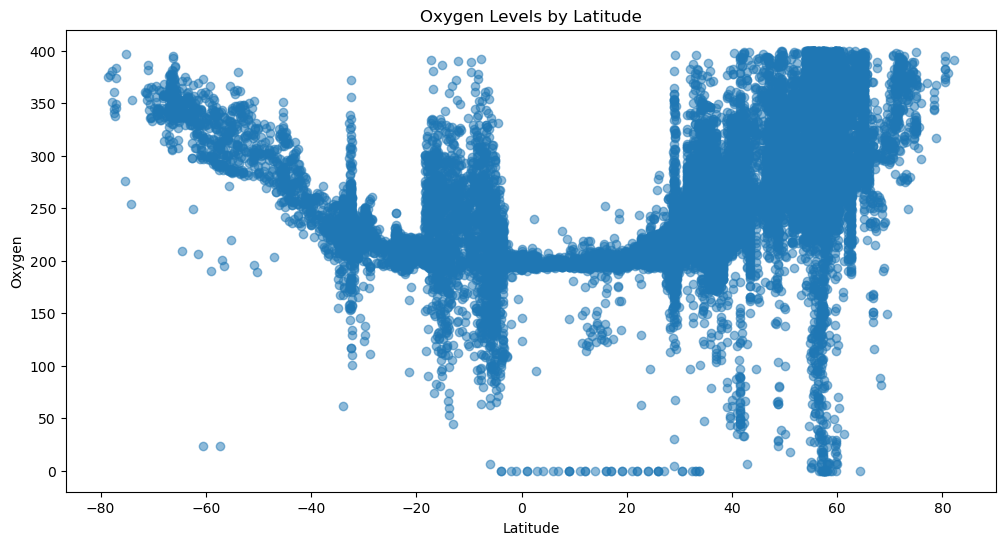

In [11]:
# Oxygen vs Latitude - show geographic patterns
plt.figure(figsize=(12, 6))
plt.scatter(training_df['Latitude'], training_df['Oxygen'], alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('Oxygen')
plt.title('Oxygen Levels by Latitude')
plt.savefig('../Results/Figures/oxygen_v_latitude.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis

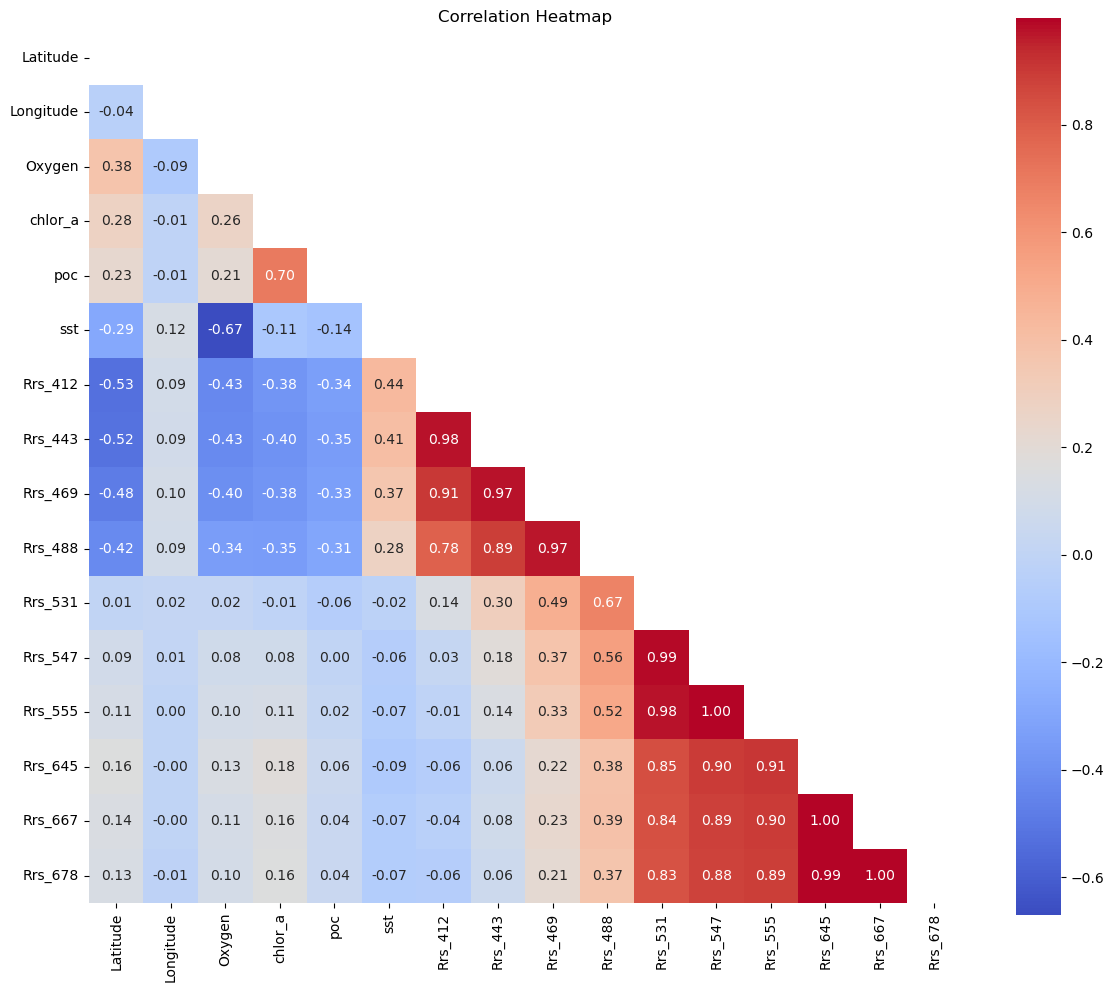

In [12]:
# Generate a correlation heatmap to visualize relationships between numeric variables
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix for numeric variables
corr = training_df[numeric_cols].corr()

# Create a mask for the upper triangle to avoid redundant display
mask = np.triu(np.ones_like(corr, dtype=bool))

# Generate the heatmap with annotations
sns.heatmap(
   corr,
   mask=mask,
   annot=True,
   fmt=".2f",
   cmap="coolwarm",
   square=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig('../Results/Figures/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# Get correlations with oxygen, sorted by strength
oxygen_corr = training_df[numeric_cols].corr()['Oxygen'].drop('Oxygen')
oxygen_corr_sorted = oxygen_corr.abs().sort_values(ascending=False)

print("Variables correlation with Oxygen:")
for var in oxygen_corr_sorted.index:
    print(f"{var}: {oxygen_corr[var]:.3f}")

Variables correlation with Oxygen:
sst: -0.671
Rrs_412: -0.434
Rrs_443: -0.429
Rrs_469: -0.404
Latitude: 0.378
Rrs_488: -0.339
chlor_a: 0.262
poc: 0.208
Rrs_645: 0.133
Rrs_667: 0.107
Rrs_555: 0.104
Rrs_678: 0.102
Longitude: -0.086
Rrs_547: 0.084
Rrs_531: 0.016


## Feature Engineering

In [14]:
# Exclude non-features
exclude_cols = ['Cast_id', 'Date']

training_df = training_df.drop(columns=exclude_cols)
validation_df = validation_df.drop(columns=exclude_cols)
testing_df = testing_df.drop(columns=exclude_cols)

training_df.head()

,Latitude,Longitude,Year,Month,Day,Oxygen,chlor_a,poc,sst,Rrs_412,Rrs_443,Rrs_469,Rrs_488,Rrs_531,Rrs_547,Rrs_555,Rrs_645,Rrs_667,Rrs_678
0,54.4027,18.9570,2002,7,4,302.0,8.417533,328.200012,16.174999,0.002044,0.001598,0.001790,0.001616,0.002596,0.002656,0.002612,0.000610,0.000410,0.000472
1,60.3885,27.6550,2002,7,4,314.0,18.162699,581.000000,15.719999,0.000892,0.001096,0.001390,0.001538,0.002776,0.003146,0.003194,0.001868,0.001632,0.001528
2,60.2530,27.2468,2002,7,4,311.0,12.316717,564.599976,13.785000,0.001150,0.000894,0.001390,0.001374,0.002294,0.002532,0.002534,0.001382,0.001196,0.001146
3,54.5772,18.8613,2002,7,4,343.0,2.442546,220.199997,16.344999,0.003256,0.002724,0.002788,0.002608,0.003222,0.003062,0.002840,0.000760,0.000564,0.000568
4,54.5720,18.8230,2002,7,4,336.0,3.658302,250.399994,16.295000,0.003024,0.002490,0.002606,0.002408,0.003170,0.003150,0.002944,0.000736,0.000494,0.000486


In [15]:
# Helper Functions for Feature Engineering

def get_season(row):
    """Hemisphere-aware seasonal classification"""
    month, day, lat = row['Month'], row['Day'], row['Latitude']

    if lat >= 0.0:  # northern hemisphere
        if (month == 12 and day >= 21) or (month in [1, 2]) or (month == 3 and day <= 20):
            return 'Winter'
        elif (month == 3 and day >= 21) or (month in [4, 5]) or (month == 6 and day <= 20):
            return 'Spring'
        elif (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day <= 22):
            return 'Summer'
        else:
            return 'Autumn'
    else:  # southern hemisphere
        if (month == 12 and day >= 21) or (month in [1, 2]) or (month == 3 and day <= 20):
            return 'Summer'
        elif (month == 3 and day >= 21) or (month in [4, 5]) or (month == 6 and day <= 20):
            return 'Autumn'
        elif (month == 6 and day >= 21) or (month in [7, 8]) or (month == 9 and day <= 22):
            return 'Winter'
        else:
            return 'Spring'

def temperature_features(df):
    """
    Temperature-based features.
    Includes SST anomaly and non-linear transformations.
    """
    # SST anomaly (teammate's feature)
    df['sst_anomaly'] = df['sst'] - df.groupby('season')['sst'].transform('mean')

    # Non-linear temperature effects
    df['sst_squared'] = df['sst'] ** 2
    df['sst_cubed'] = df['sst'] ** 3

    return df

def log_transform_skewed_features(df):
    """
    Log transform only HIGHLY skewed features (skewness > 4).
    Keeps both original and log versions for correlation testing.
    """
    # Only the most extremely skewed features - from above analysis
    highly_skewed = [
        'Rrs_667',      # 6.66
        'Rrs_678',      # 6.57
        'Rrs_645',      # 6.27
        'poc',          # 6.20
        'Rrs_531',      # 4.92
        'Rrs_547',      # 4.85
        'Rrs_555',      # 4.76
        'chlor_a',      # 4.25
    ]

    for feature in highly_skewed:
        if feature in df.columns:
            df[f'log_{feature}'] = np.log(df[feature].replace(0, np.nan).clip(lower=1e-10))

    return df


def biomass_ratios(df):
    """
    Biomass efficiency indicators.
    Includes POC/Chlor_a and inverse ratio.
    """
    # POC/Chlor_a ratio
    df['poc_chla_ratio'] = (df['poc'] / df['chlor_a']).replace([np.inf, -np.inf], np.nan)

    # Inverse ratio
    df['chlor_poc_ratio'] = (df['chlor_a'] / df['poc']).replace([np.inf, -np.inf], np.nan)

    return df


def spectral_ratios(df):
    """
    Spectral band ratios for water properties.
    Includes standard ocean color ratios.
    """
    # Blue-green ratio
    df['ratio_443_547'] = (df['Rrs_443'] / df['Rrs_547']).replace([np.inf, -np.inf], np.nan)

    # Standard blue/green ratios (chlorophyll indicators)
    df['ratio_443_555'] = (df['Rrs_443'] / df['Rrs_555']).replace([np.inf, -np.inf], np.nan)

    # Red/Blue ratios (biomass indicators)
    df['ratio_667_443'] = (df['Rrs_667'] / df['Rrs_443']).replace([np.inf, -np.inf], np.nan)

    # Red/Green ratios
    df['ratio_667_555'] = (df['Rrs_667'] / df['Rrs_555']).replace([np.inf, -np.inf], np.nan)

    # Green/Red (turbidity indicator)
    df['ratio_555_667'] = (df['Rrs_555'] / df['Rrs_667']).replace([np.inf, -np.inf], np.nan)

    return df


def normalized_indices(df):
    """Normalized difference indices (robust to atmospheric effects)"""
    # Normalized Difference Chlorophyll Index
    df['ndci'] = ((df['Rrs_667'] - df['Rrs_645']) /
                  (df['Rrs_667'] + df['Rrs_645'])).replace([np.inf, -np.inf], np.nan)

    # Water-adapted NDVI
    df['ndvi_water'] = ((df['Rrs_555'] - df['Rrs_667']) /
                        (df['Rrs_555'] + df['Rrs_667'])).replace([np.inf, -np.inf], np.nan)

    return df


def interaction_terms(df):
    """Feature interactions for non-linear relationships"""
    df['sst_chlor_interaction'] = df['sst'] * df['log_chlor_a']
    df['sst_poc_interaction'] = df['sst'] * df['poc']
    return df


def spatial_features(df):
    """Latitude-based spatial groupings"""
    df['abs_latitude'] = df['Latitude'].abs()
    return df

In [16]:
# Main Feature Engineering Function and Application

def create_all_candidate_features(df):
    """
    Apply all feature engineering transformations.
    Creates ~25 candidate features for correlation analysis with Oxygen.
    """

    # Temporal features
    df['season'] = df.apply(get_season, axis=1)
    df['day_of_year'] = pd.to_datetime(df[['Year','Month','Day']]).dt.dayofyear

    # Temperature features
    df = temperature_features(df)

    # Log transformations
    df = log_transform_skewed_features(df)

    # Biomass ratios
    df = biomass_ratios(df)

    # Spectral ratios
    df = spectral_ratios(df)

    # Normalized indices
    df = normalized_indices(df)

    # Interaction terms
    df = interaction_terms(df)

    # Spatial features
    df = spatial_features(df)

    return df

# Apply to training data only
training_df = create_all_candidate_features(training_df)

Correlation with Oxygen:

sst_squared             -0.649538
sst_anomaly             -0.644817
abs_latitude             0.636160
sst_cubed               -0.605518
log_chlor_a              0.493998
ratio_443_547           -0.473841
ratio_443_555           -0.470627
sst_chlor_interaction    0.467494
log_poc                  0.464725
poc_chla_ratio          -0.360942
chlor_poc_ratio          0.282836
ratio_667_555            0.221971
day_of_year             -0.178083
log_Rrs_555              0.161041
log_Rrs_645              0.156912
log_Rrs_547              0.111549
sst_poc_interaction      0.110473
ndvi_water              -0.072214
log_Rrs_667              0.047618
log_Rrs_531             -0.039039
log_Rrs_678              0.034261
ndci                    -0.009614
ratio_555_667            0.004531
ratio_667_443            0.001200
dtype: float64


Absolute Correlation with Oxygen:

sst_squared              0.649538
sst_anomaly              0.644817
abs_latitude             0.636160
sst_

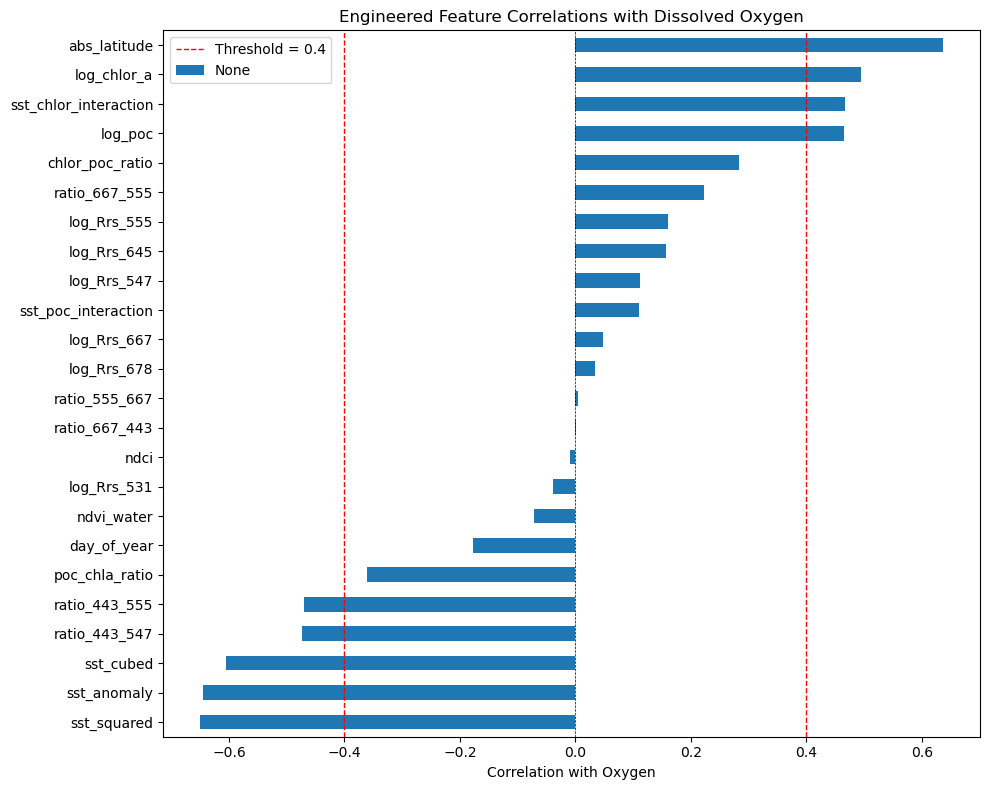

In [17]:
# Correlation Analysis of Numeric Features

# List of numerica engineered features
engineered_features = [
    'day_of_year',
    'sst_anomaly', 'sst_squared', 'sst_cubed',
    'log_chlor_a', 'log_poc',
    'log_Rrs_531', 'log_Rrs_547', 'log_Rrs_555',
    'log_Rrs_645', 'log_Rrs_667', 'log_Rrs_678',
    'poc_chla_ratio', 'chlor_poc_ratio',
    'ratio_443_547', 'ratio_443_555', 'ratio_667_443', 'ratio_667_555', 'ratio_555_667',
    'ndci', 'ndvi_water',
    'sst_chlor_interaction', 'sst_poc_interaction',
    'abs_latitude'
]

# Calculate correlations with Oxygen
correlations = training_df[engineered_features].corrwith(training_df['Oxygen'])
correlations_abs = correlations.abs()

# Sort by absolute correlation
print("Correlation with Oxygen:\n")
print(correlations.sort_values(key=abs, ascending=False))
print("\n" + "="*50 + "\n")
print("Absolute Correlation with Oxygen:\n")
print(correlations_abs.sort_values(ascending=False))

# Visualize correlations

plt.figure(figsize=(10, 8))
correlations_sorted = correlations.sort_values()
correlations_sorted.plot(kind='barh')
plt.xlabel('Correlation with Oxygen')
plt.title('Engineered Feature Correlations with Dissolved Oxygen')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(x=0.4, color='red', linestyle='--', linewidth=1, label='Threshold = 0.4')
plt.axvline(x=-0.4, color='red', linestyle='--', linewidth=1)
plt.legend()
plt.tight_layout()
plt.savefig('../Results/Figures/engineered_features_correlation_v_oxygen.png', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# Feature Selection

# Select features with |correlation| > 0.4
THRESHOLD = 0.4
final_features = correlations_abs[correlations_abs > THRESHOLD].index.tolist()

print(f"\n{'='*50}")
print(f"Features with |corr| > {THRESHOLD}: {len(final_features)}")
print(f"{'='*50}")
print(final_features)


Features with |corr| > 0.4: 9
['sst_anomaly', 'sst_squared', 'sst_cubed', 'log_chlor_a', 'log_poc', 'ratio_443_547', 'ratio_443_555', 'sst_chlor_interaction', 'abs_latitude']


In [21]:
# Create Final Features on Validation and Test Sets

def create_final_features_only(df):
    """
    Create only the selected engineered features.
    This function creates the features from final_features + season.
    """

    # Categorical features
    df['season'] = df.apply(get_season, axis=1)

    # Temperature features
    df['sst_squared'] = df['sst'] ** 2
    df['sst_cubed'] = df['sst'] ** 3
    df['sst_anomaly'] = df['sst'] - df.groupby('season')['sst'].transform('mean')

    # Spatial features
    df['abs_latitude'] = df['Latitude'].abs()

    # Biomass features
    df['log_chlor_a'] = np.log(df['chlor_a'].replace(0, np.nan).clip(lower=1e-10))
    df['log_poc'] = np.log(df['poc'].replace(0, np.nan).clip(lower=1e-10))

    # Spectral ratio features
    df['ratio_443_547'] = (df['Rrs_443'] / df['Rrs_547']).replace([np.inf, -np.inf], np.nan)
    df['ratio_443_555'] = (df['Rrs_443'] / df['Rrs_555']).replace([np.inf, -np.inf], np.nan)

    # Interaction features
    df['sst_chlor_interaction'] = df['sst'] * df['log_chlor_a']

    return df

# Apply to validation and test sets
validation_df = create_final_features_only(validation_df)
testing_df = create_final_features_only(testing_df)


In [22]:
# Multicollinearity Check and Redundant Feature Removal

# Selected numerical features
selected_numerical = [f for f in final_features if f in training_df.columns]

# Calculate correlation matrix
selected_corr_matrix = training_df[selected_numerical].corr()

# Identify features to drop (|r| > 0.95 with another feature)
features_to_drop = set()
REDUNDANCY_THRESHOLD = 0.95

for i in range(len(selected_numerical)):
    for j in range(i+1, len(selected_numerical)):
        if abs(selected_corr_matrix.iloc[i, j]) > REDUNDANCY_THRESHOLD:
            feat_i = selected_numerical[i]
            feat_j = selected_numerical[j]

            # Keep the one with higher correlation to Oxygen
            if abs(correlations[feat_i]) >= abs(correlations[feat_j]):
                features_to_drop.add(feat_j)
            else:
                features_to_drop.add(feat_i)

print(f"Features to drop due to redundancy (|r| > {REDUNDANCY_THRESHOLD}):")
print(features_to_drop)

# Remove redundant features from must_keep
final_features_refined = [f for f in final_features if f not in features_to_drop]

print(f"\nFinal features after redundancy removal: {len(final_features_refined)}")
print(final_features_refined)


Features to drop due to redundancy (|r| > 0.95):
{'sst_cubed', 'log_poc', 'ratio_443_555'}

Final features after redundancy removal: 6
['sst_anomaly', 'sst_squared', 'log_chlor_a', 'ratio_443_547', 'sst_chlor_interaction', 'abs_latitude']


In [23]:
# Filter to Final Columns

# Include Season in final features
final_features = final_features + ['season']

print(f"\nFinal engineered features: {len(final_features)}")
print(final_features)

# Original features to keep for reference
original_features = [
    'Latitude', 'Longitude', 'Year', 'Month', 'Day',
    'chlor_a', 'poc', 'sst',
    'Rrs_412', 'Rrs_443', 'Rrs_469', 'Rrs_488',
    'Rrs_531', 'Rrs_547', 'Rrs_555',
    'Rrs_645', 'Rrs_667', 'Rrs_678'
]

# Combine: engineered + original + target
final_columns = original_features + final_features + ['Oxygen']

# Remove duplicates (in case any overlap)
final_columns = list(dict.fromkeys(final_columns))

# Keep only these columns in each dataset
training_df = training_df[final_columns]
validation_df = validation_df[final_columns]
testing_df = testing_df[final_columns]


print("Dataset shapes:")
print(f"  training_df: {training_df.shape}")
print(f"  validation_df: {validation_df.shape}")
print(f"  testing_df: {testing_df.shape}")
print(f"\nTotal columns: {len(final_columns)}")


Final engineered features: 10
['sst_anomaly', 'sst_squared', 'sst_cubed', 'log_chlor_a', 'log_poc', 'ratio_443_547', 'ratio_443_555', 'sst_chlor_interaction', 'abs_latitude', 'season']
Dataset shapes:
  training_df: (32423, 29)
  validation_df: (6922, 29)
  testing_df: (7103, 29)

Total columns: 29


In [24]:
training_df.head()

,Latitude,Longitude,Year,Month,Day,chlor_a,poc,sst,Rrs_412,Rrs_443,...,sst_squared,sst_cubed,log_chlor_a,log_poc,ratio_443_547,ratio_443_555,sst_chlor_interaction,abs_latitude,season,Oxygen
0,54.4027,18.9570,2002,7,4,8.417533,328.200012,16.174999,0.002044,0.001598,...,261.630600,4231.874761,2.130317,5.793623,0.601657,0.611792,34.457872,54.4027,Summer,302.0
1,60.3885,27.6550,2002,7,4,18.162699,581.000000,15.719999,0.000892,0.001096,...,247.118378,3884.700739,2.899370,6.364751,0.348379,0.343144,45.578094,60.3885,Summer,314.0
2,60.2530,27.2468,2002,7,4,12.316717,564.599976,13.785000,0.001150,0.000894,...,190.026221,2619.511425,2.510957,6.336117,0.353081,0.352802,34.613548,60.2530,Summer,311.0
3,54.5772,18.8613,2002,7,4,2.442546,220.199997,16.344999,0.003256,0.002724,...,267.159003,4366.713713,0.893041,5.394536,0.889615,0.959155,14.596751,54.5772,Summer,343.0
4,54.5720,18.8230,2002,7,4,3.658302,250.399994,16.295000,0.003024,0.002490,...,265.527027,4326.762933,1.296999,5.523060,0.790476,0.845788,21.134600,54.5720,Summer,336.0


In [25]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32423 entries, 0 to 35228
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Latitude               32423 non-null  float64
 1   Longitude              32423 non-null  float64
 2   Year                   32423 non-null  int64  
 3   Month                  32423 non-null  int64  
 4   Day                    32423 non-null  int64  
 5   chlor_a                32423 non-null  float64
 6   poc                    32423 non-null  float64
 7   sst                    32423 non-null  float64
 8   Rrs_412                32423 non-null  float64
 9   Rrs_443                32423 non-null  float64
 10  Rrs_469                32423 non-null  float64
 11  Rrs_488                32423 non-null  float64
 12  Rrs_531                32423 non-null  float64
 13  Rrs_547                32423 non-null  float64
 14  Rrs_555                32423 non-null  float64
 15  Rr

In [26]:
# Export Processed Data Split Sets
training_df.to_csv('../Data/Data Splits/Processed/Training Set.csv', index=False)
validation_df.to_csv('../Data/Data Splits/Processed/Validation Set.csv', index=False)
testing_df.to_csv('../Data/Data Splits/Processed/Testing Set.csv', index=False)

In [27]:
# Check if same locations appear in train and test
train_locations = set(zip(training_df['Latitude'].round(1), training_df['Longitude'].round(1)))
test_locations = set(zip(testing_df['Latitude'].round(1), testing_df['Longitude'].round(1)))

overlap = train_locations.intersection(test_locations)
print(f"Locations in both train and test: {len(overlap)}")
print(f"Train-only locations: {len(train_locations - overlap)}")
print(f"Test-only locations: {len(test_locations - overlap)}")
print(f"Overlap percentage: {len(overlap)/len(test_locations)*100:.1f}%")

Locations in both train and test: 1489
Train-only locations: 9342
Test-only locations: 1681
Overlap percentage: 47.0%
